## Ames One Hot Encoding and Ordinal Encoding
* Train XGBoost models with the following:
    * Numerical Columns + All Nominal Categorical Columns (One Hot Encoded)
    * Numerical Columns + All Nominal Categorical Columns (One Hot Encoded) + PCA
    * Numerical Columns + Selected Nominal Categorical Columns (One Hot Encoded)
    * Numerical Columns + All Categorical Columns (One Hot Encoded/Ordinal Encoding)

### Loading Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from IPython.display import HTML, display
import tabulate

In [3]:
#importing module that wraps preprocessing steps
import Housing_Preprocessing as hp

In [11]:
#reimport if necessary (edit file after already imported)
import importlib
importlib.reload(hp)

<module 'Housing_Preprocessing' from '/Users/Temp/Data4381/Housing_Preprocessing.py'>

In [4]:
#loading the dataset/applying preprocessing
df=hp.housing_preprocessing('AmesHousing.csv',target="Categorical")
df

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,Price Bins
0,20,RL,141.0,31770,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,0,No Pool,No Fence,No Misc Feature,0,5,2010,WD,Normal,$180k-$260k
1,20,RH,80.0,11622,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,No Misc Feature,0,6,2010,WD,Normal,$100k-$180k
2,20,RL,81.0,14267,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,0,No Pool,No Fence,Gar2,12500,6,2010,WD,Normal,$100k-$180k
3,20,RL,93.0,11160,Pave,No Alley Access,Reg,Lvl,AllPub,Corner,...,0,No Pool,No Fence,No Misc Feature,0,4,2010,WD,Normal,$180k-$260k
4,60,RL,74.0,13830,Pave,No Alley Access,IR1,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,No Misc Feature,0,3,2010,WD,Normal,$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,No Alley Access,IR1,Lvl,AllPub,CulDSac,...,0,No Pool,GdPrv,No Misc Feature,0,3,2006,WD,Normal,$100k-$180k
2926,20,RL,74.0,8885,Pave,No Alley Access,IR1,Low,AllPub,Inside,...,0,No Pool,MnPrv,No Misc Feature,0,6,2006,WD,Normal,$100k-$180k
2927,85,RL,62.0,10441,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,Shed,700,7,2006,WD,Normal,$100k-$180k
2928,20,RL,77.0,10010,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,0,No Pool,No Fence,No Misc Feature,0,4,2006,WD,Normal,$100k-$180k


In [5]:
#columns that need encoding (categorical)
need_onehot=['MS SubClass','MS Zoning','Street','Alley','Land Contour','Lot Config','Neighborhood','Condition 1','Condition 2','Bldg Type','House Style','Roof Style','Roof Matl','Exterior 1st','Exterior 2nd','Mas Vnr Type','Foundation','Heating','Central Air','Garage Type','Misc Feature','Sale Type','Sale Condition']
label_encoding=['Lot Shape','Utilities','Land Slope','Overall Qual','Overall Cond','Exter Qual','Exter Cond','Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2','Heating QC','Electrical','Kitchen Qual','Functional','Fireplace Qu','Garage Finish','Garage Qual','Garage Cond','Paved Drive','Pool QC','Fence']


In [6]:
#missing values; only columns with missing values
df.isnull().sum()[df.isnull().sum()>0]

Lot Frontage       3
Mas Vnr Type      30
Mas Vnr Area      23
Bsmt Exposure      3
BsmtFin SF 1       1
BsmtFin Type 2     1
BsmtFin SF 2       1
Bsmt Unf SF        1
Total Bsmt SF      1
Electrical         1
Bsmt Full Bath     2
Bsmt Half Bath     2
Garage Yr Blt      2
Garage Finish      2
Garage Cars        1
Garage Area        1
Garage Qual        2
Garage Cond        2
dtype: int64

In [7]:
#drop missing values
df=df.dropna()
df

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,Price Bins
0,20,RL,141.0,31770,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,0,No Pool,No Fence,No Misc Feature,0,5,2010,WD,Normal,$180k-$260k
1,20,RH,80.0,11622,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,No Misc Feature,0,6,2010,WD,Normal,$100k-$180k
2,20,RL,81.0,14267,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,0,No Pool,No Fence,Gar2,12500,6,2010,WD,Normal,$100k-$180k
3,20,RL,93.0,11160,Pave,No Alley Access,Reg,Lvl,AllPub,Corner,...,0,No Pool,No Fence,No Misc Feature,0,4,2010,WD,Normal,$180k-$260k
4,60,RL,74.0,13830,Pave,No Alley Access,IR1,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,No Misc Feature,0,3,2010,WD,Normal,$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,No Alley Access,IR1,Lvl,AllPub,CulDSac,...,0,No Pool,GdPrv,No Misc Feature,0,3,2006,WD,Normal,$100k-$180k
2926,20,RL,74.0,8885,Pave,No Alley Access,IR1,Low,AllPub,Inside,...,0,No Pool,MnPrv,No Misc Feature,0,6,2006,WD,Normal,$100k-$180k
2927,85,RL,62.0,10441,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,Shed,700,7,2006,WD,Normal,$100k-$180k
2928,20,RL,77.0,10010,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,0,No Pool,No Fence,No Misc Feature,0,4,2006,WD,Normal,$100k-$180k


In [ ]:
#numerical columns only
nums=df.drop(columns=need_onehot)
nums=nums.drop(columns=label_encoding)
nums=nums.drop(columns=['Price Bins'])
nums

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,528.0,210,62,0,0,0,0,0,5,2010
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,730.0,140,0,0,0,120,0,0,6,2010
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,312.0,393,36,0,0,0,0,12500,6,2010
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,522.0,0,0,0,0,0,0,0,4,2010
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,482.0,212,34,0,0,0,0,0,3,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,588.0,120,0,0,0,0,0,0,3,2006
2926,74.0,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,484.0,164,0,0,0,0,0,0,6,2006
2927,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,0.0,80,32,0,0,0,0,700,7,2006
2928,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,418.0,240,38,0,0,0,0,0,4,2006


### XGBoost: Numerical Columns + One Hot Encoding ALL Nominal Categorical Columns
* stratified 80/20 train/test split

In [ ]:
#One Hot Encoding
encoder=OneHotEncoder(sparse_output=False)
encoder.fit(df[need_onehot])
encoded_cols=encoder.get_feature_names_out(need_onehot)
OHencoded=pd.DataFrame(encoder.transform(df[need_onehot]),columns=encoded_cols)
OHencoded

,MS SubClass_20,MS SubClass_30,MS SubClass_40,MS SubClass_45,MS SubClass_50,MS SubClass_60,MS SubClass_70,MS SubClass_75,MS SubClass_80,MS SubClass_85,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2883,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2884,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2885,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2886,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [40]:
NumsOneHot=pd.concat([nums.reset_index(drop=True),OHencoded.reset_index(drop=True),df['Price Bins'].reset_index(drop=True)],axis=1)
NumsOneHot

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial,Price Bins
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,$180k-$260k
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,$100k-$180k
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,$100k-$180k
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,$180k-$260k
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2883,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,$100k-$180k
2884,74.0,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,$100k-$180k
2885,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,$100k-$180k
2886,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,$100k-$180k


In [42]:
#train/test split
X = NumsOneHot.iloc[:,:-1] #excluding  target var
y = NumsOneHot.iloc[:,-1:] #only categorical target var

#ordinal labeling of target variable
labels=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k']
encoder=OrdinalEncoder(categories=[labels])
y=encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y,random_state=123)

In [43]:
X_train.columns=X_train.columns.astype(str)
X_test.columns=X_test.columns.astype(str)

In [12]:
# Model Training
xgb_classifier = xgb.XGBClassifier()
xgb_classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [13]:
#predictions
y_pred = xgb_classifier.predict(X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores = dict()
scores['XGBoost OH']=dict()
scores['XGBoost OH']['Accuracy'] = accuracy_score(y_test, y_pred)
scores['XGBoost OH']['Precision'] = precision_score(y_test, y_pred,average='macro')
scores['XGBoost OH']['Recall'] = recall_score(y_test, y_pred,average='macro')
scores['XGBoost OH']['F1'] = f1_score(y_test, y_pred,average='macro')
scores['XGBoost OH']['ConfusionMatrix']=confusion_matrix(y_test,xgb_classifier.predict(X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost OH,0.804498,0.756868,0.70395,0.726767,[[ 28 22 0 0 0] [ 10 277 21 0 0] [ 0 27 106 11 1] [ 0 0 14 47 2] [ 0 0 0 5 7]]


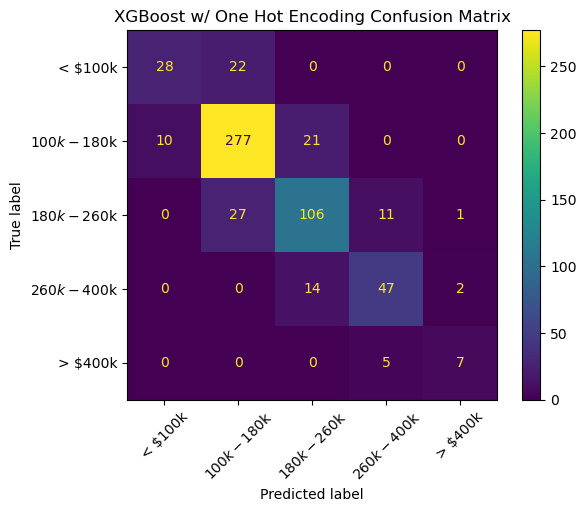

In [112]:
confusion=ConfusionMatrixDisplay(scores['XGBoost OH']['ConfusionMatrix'],display_labels=labels)
confusion.plot()
plt.title(f'XGBoost w/ One Hot Encoding Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

### XGBoost: PCA + Numerical Columns + One Hot Encoding ALL Nominal Categorical Columns

In [15]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [ ]:
pipeline=Pipeline([('pca', PCA(n_components=75)),('xgb', xgb.XGBClassifier())])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('pca', PCA(n_components=75)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [ ]:
#examining PCA
pca=pipeline.named_steps['pca']
comps=pd.DataFrame(pca.components_,columns=X_train.columns,index=[f'PCA{i+1}' for i in range(pca.n_components_)])

for i in range(5):
    print(f"\nTop features for PCA{i+1}")
    print(comps.iloc[i].abs().sort_values(ascending=False).head(10))


Top features for PCA1
Lot Area         0.999613
Gr Liv Area      0.016096
1st Flr SF       0.013799
Total Bsmt SF    0.012570
BsmtFin SF 1     0.010087
Garage Area      0.005157
Garage Yr Blt    0.003587
Mas Vnr Area     0.002601
Wood Deck SF     0.002294
2nd Flr SF       0.002256
Name: PC1, dtype: float64

Top features for PCA2
Gr Liv Area      0.548791
Total Bsmt SF    0.515723
1st Flr SF       0.433748
BsmtFin SF 1     0.304673
Bsmt Unf SF      0.224096
Garage Area      0.190231
Garage Yr Blt    0.179208
Mas Vnr Area     0.119425
2nd Flr SF       0.114111
Wood Deck SF     0.045742
Name: PC2, dtype: float64

Top features for PCA3
2nd Flr SF       0.591272
BsmtFin SF 1     0.522665
Gr Liv Area      0.417615
Bsmt Unf SF      0.330497
Total Bsmt SF    0.232784
1st Flr SF       0.182694
Garage Yr Blt    0.056723
BsmtFin SF 2     0.040617
Misc Val         0.016874
Open Porch SF    0.015274
Name: PC3, dtype: float64

Top features for PCA4
Bsmt Unf SF      0.675807
2nd Flr SF       0.43356

Top 10 features for the first five PCA components are all size/area related (square feet) with some Year Built related columns
* Note that all these features are numerical

In [18]:
#predictions
y_pred_PCA = pipeline.predict(X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGBoost PCA OH']=dict()
scores['XGBoost PCA OH']['Accuracy'] = accuracy_score(y_test, y_pred_PCA)
scores['XGBoost PCA OH']['Precision'] = precision_score(y_test, y_pred_PCA,average='macro')
scores['XGBoost PCA OH']['Recall'] = recall_score(y_test, y_pred_PCA,average='macro')
scores['XGBoost PCA OH']['F1'] = f1_score(y_test, y_pred_PCA,average='macro')
scores['XGBoost PCA OH']['ConfusionMatrix']=confusion_matrix(y_test,pipeline.predict(X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost OH,0.804498,0.756868,0.70395,0.726767,[[ 28 22 0 0 0] [ 10 277 21 0 0] [ 0 27 106 11 1] [ 0 0 14 47 2] [ 0 0 0 5 7]]
XGBoost PCA OH,0.782007,0.697872,0.670496,0.680096,[[ 27 23 0 0 0] [ 10 275 22 1 0] [ 0 28 104 11 2] [ 0 1 18 39 5] [ 0 0 0 5 7]]


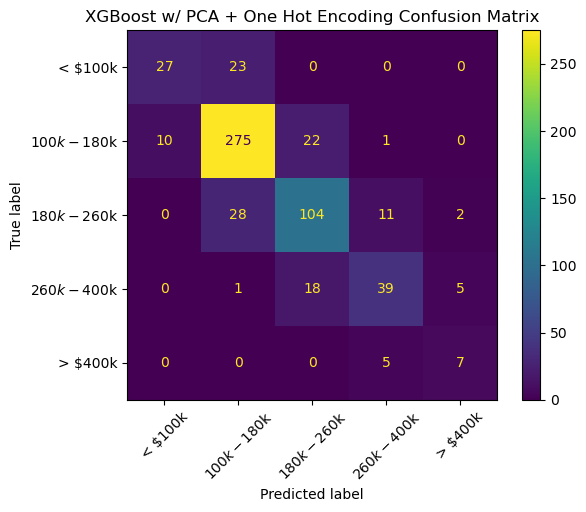

In [111]:
confusion=ConfusionMatrixDisplay(scores['XGBoost PCA OH']['ConfusionMatrix'],display_labels=labels)
confusion.plot()
plt.title(f'XGBoost w/ PCA + One Hot Encoding Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

### Numerical Columns + Nominal Categorical Columns + SMOTE

In [25]:
from imblearn.pipeline import Pipeline as pipelineIM
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

In [44]:
smote_pipeline=pipelineIM([('smote', SMOTE(random_state=123)),('xgb', xgb.XGBClassifier())])
smote_pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=123)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [23]:
# predictions
y_pred_OH_SMOTE = smote_pipeline.predict(X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB SMOTE+OH']=dict()
scores['XGB SMOTE+OH']['Accuracy'] = accuracy_score(y_test, y_pred_OH_SMOTE)
scores['XGB SMOTE+OH']['Precision'] = precision_score(y_test, y_pred_OH_SMOTE,average='macro')
scores['XGB SMOTE+OH']['Recall'] = recall_score(y_test, y_pred_OH_SMOTE,average='macro')
scores['XGB SMOTE+OH']['F1'] = f1_score(y_test, y_pred_OH_SMOTE,average='macro')
scores['XGB SMOTE+OH']['ConfusionMatrix']=confusion_matrix(y_test,smote_pipeline.predict(X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost OH,0.804498,0.756868,0.70395,0.726767,[[ 28 22 0 0 0] [ 10 277 21 0 0] [ 0 27 106 11 1] [ 0 0 14 47 2] [ 0 0 0 5 7]]
XGBoost PCA OH,0.782007,0.697872,0.670496,0.680096,[[ 27 23 0 0 0] [ 10 275 22 1 0] [ 0 28 104 11 2] [ 0 1 18 39 5] [ 0 0 0 5 7]]
XGB SMOTE+OH,0.807958,0.769603,0.766213,0.764015,[[ 31 19 0 0 0] [ 7 274 26 1 0] [ 0 25 103 16 1] [ 0 0 11 49 3] [ 0 0 0 2 10]]


In [26]:
#Hyperparameter Tuning
param_grid = {
    'xgb__n_estimators': [600, 800, 1000, 1200],
    'xgb__max_depth': [7, 9, 11, 13],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.3],
    'xgb__colsample_bytree': [0.7, 0.9, 1],
    'xgb__gamma': [0, 0.1, 0.3, 0.5],
    'xgb__reg_alpha': [0, 0.1, 0.5, 1],
    'xgb__reg_lambda': [1, 3, 5, 10]
}
grid_search = RandomizedSearchCV(smote_pipeline, param_grid, cv=5, scoring='f1_macro', n_iter=40, verbose=2)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.1, xgb__learning_rate=0.3, xgb__max_depth=13, xgb__n_estimators=1200, xgb__reg_alpha=0, xgb__reg_lambda=10; total time=   3.6s
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.1, xgb__learning_rate=0.3, xgb__max_depth=13, xgb__n_estimators=1200, xgb__reg_alpha=0, xgb__reg_lambda=10; total time=   3.5s
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.1, xgb__learning_rate=0.3, xgb__max_depth=13, xgb__n_estimators=1200, xgb__reg_alpha=0, xgb__reg_lambda=10; total time=   3.4s
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.1, xgb__learning_rate=0.3, xgb__max_depth=13, xgb__n_estimators=1200, xgb__reg_alpha=0, xgb__reg_lambda=10; total time=   3.4s
[CV] END xgb__colsample_bytree=0.9, xgb__gamma=0.1, xgb__learning_rate=0.3, xgb__max_depth=13, xgb__n_estimators=1200, xgb__reg_alpha=0, xgb__reg_lambda=10; total time=   3.8s
[CV] END xgb__colsample_bytree=1, xgb__gamma=0.3, xgb__lea

In [27]:
# Obtaining the best performing model from the grid search results
best_model = grid_search.best_estimator_

# predictions
y_pred_ht = best_model.predict(X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB SMOTE+OH HT']=dict()
scores['XGB SMOTE+OH HT']['Accuracy'] = accuracy_score(y_test, y_pred_ht)
scores['XGB SMOTE+OH HT']['Precision'] = precision_score(y_test, y_pred_ht,average='macro')
scores['XGB SMOTE+OH HT']['Recall'] = recall_score(y_test, y_pred_ht,average='macro')
scores['XGB SMOTE+OH HT']['F1'] = f1_score(y_test, y_pred_ht,average='macro')
scores['XGB SMOTE+OH HT']['ConfusionMatrix']=confusion_matrix(y_test,best_model.predict(X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))


,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost OH,0.804498,0.756868,0.70395,0.726767,[[ 28 22 0 0 0] [ 10 277 21 0 0] [ 0 27 106 11 1] [ 0 0 14 47 2] [ 0 0 0 5 7]]
XGBoost PCA OH,0.782007,0.697872,0.670496,0.680096,[[ 27 23 0 0 0] [ 10 275 22 1 0] [ 0 28 104 11 2] [ 0 1 18 39 5] [ 0 0 0 5 7]]
XGB SMOTE+OH,0.807958,0.769603,0.766213,0.764015,[[ 31 19 0 0 0] [ 7 274 26 1 0] [ 0 25 103 16 1] [ 0 0 11 49 3] [ 0 0 0 2 10]]
XGB SMOTE+OH HT,0.799308,0.73979,0.755391,0.7428,[[ 31 19 0 0 0] [ 9 272 26 1 0] [ 0 25 103 16 1] [ 0 0 12 46 5] [ 0 0 0 2 10]]


### Feature Importance of XGB SMOTE+OH Model

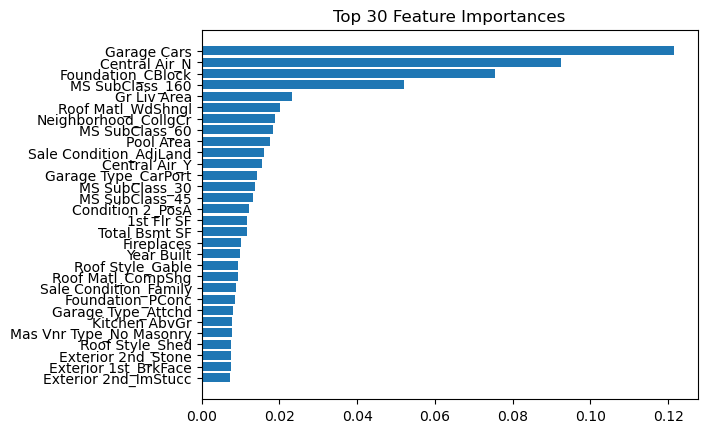

In [45]:
model=smote_pipeline.named_steps['xgb']
importance=model.feature_importances_
feature_importance=pd.DataFrame({'feature': X_train.columns,'importance': model.feature_importances_}).sort_values('importance', ascending=False)

#Plot of Feature Importance
top_30=feature_importance.head(30)

plt.figure()
plt.barh(top_30['feature'], top_30['importance'])
plt.gca().invert_yaxis()
plt.title('Top 30 Feature Importances')
plt.show()

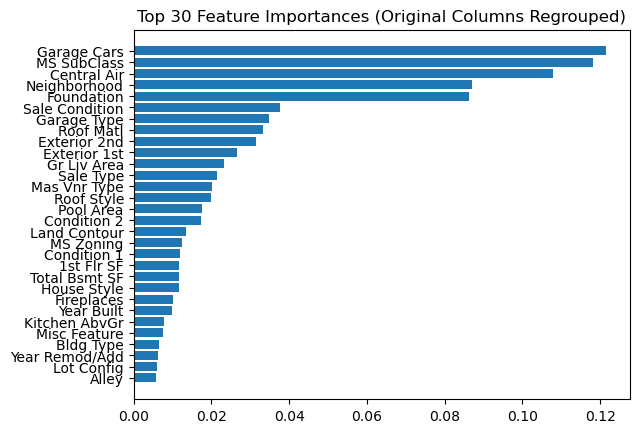

In [54]:
#Feature Importance after regrouping origincal columns (pre-One Hot Encoding)
original_OH_cols = {col: col.split('_')[0] for col in X_train.columns}
feature_importance['original_feature']=feature_importance['feature'].map(original_OH_cols)

agg_importance = (feature_importance.groupby('original_feature')['importance'].sum().sort_values(ascending=False).reset_index())

#Plot of Feature Importance (Original Columns Regrouped)
agg_top_30=agg_importance.head(30)

plt.figure()
plt.barh(agg_top_30['original_feature'], agg_top_30['importance'])
plt.gca().invert_yaxis()
plt.title('Top 30 Feature Importances (Original Columns Regrouped)')
plt.show()

### Selected Numerical Columns and Nominal Categorical Columns + SMOTE

In [58]:
selected_columns=agg_top_30['original_feature'].to_list()
selected_columns

['Garage Cars',
 'MS SubClass',
 'Central Air',
 'Neighborhood',
 'Foundation',
 'Sale Condition',
 'Garage Type',
 'Roof Matl',
 'Exterior 2nd',
 'Exterior 1st',
 'Gr Liv Area',
 'Sale Type',
 'Mas Vnr Type',
 'Roof Style',
 'Pool Area',
 'Condition 2',
 'Land Contour',
 'MS Zoning',
 'Condition 1',
 '1st Flr SF',
 'Total Bsmt SF',
 'House Style',
 'Fireplaces',
 'Year Built',
 'Kitchen AbvGr',
 'Misc Feature',
 'Bldg Type',
 'Year Remod/Add',
 'Lot Config',
 'Alley']

In [59]:
select=df[selected_columns]
select

,Garage Cars,MS SubClass,Central Air,Neighborhood,Foundation,Sale Condition,Garage Type,Roof Matl,Exterior 2nd,Exterior 1st,...,Total Bsmt SF,House Style,Fireplaces,Year Built,Kitchen AbvGr,Misc Feature,Bldg Type,Year Remod/Add,Lot Config,Alley
0,2.0,20,Y,NAmes,CBlock,Normal,Attchd,CompShg,Plywood,BrkFace,...,1080.0,1Story,2,1960,1,No Misc Feature,1Fam,1960,Corner,No Alley Access
1,1.0,20,Y,NAmes,CBlock,Normal,Attchd,CompShg,VinylSd,VinylSd,...,882.0,1Story,0,1961,1,No Misc Feature,1Fam,1961,Inside,No Alley Access
2,1.0,20,Y,NAmes,CBlock,Normal,Attchd,CompShg,Wd Sdng,Wd Sdng,...,1329.0,1Story,0,1958,1,Gar2,1Fam,1958,Corner,No Alley Access
3,2.0,20,Y,NAmes,CBlock,Normal,Attchd,CompShg,BrkFace,BrkFace,...,2110.0,1Story,2,1968,1,No Misc Feature,1Fam,1968,Corner,No Alley Access
4,2.0,60,Y,Gilbert,PConc,Normal,Attchd,CompShg,VinylSd,VinylSd,...,928.0,2Story,1,1997,1,No Misc Feature,1Fam,1998,Inside,No Alley Access
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2.0,80,Y,Mitchel,CBlock,Normal,Detchd,CompShg,HdBoard,HdBoard,...,1003.0,SLvl,0,1984,1,No Misc Feature,1Fam,1984,CulDSac,No Alley Access
2926,2.0,20,Y,Mitchel,CBlock,Normal,Attchd,CompShg,HdBoard,HdBoard,...,864.0,1Story,0,1983,1,No Misc Feature,1Fam,1983,Inside,No Alley Access
2927,0.0,85,Y,Mitchel,PConc,Normal,No Garage,CompShg,Wd Shng,HdBoard,...,912.0,SFoyer,0,1992,1,Shed,1Fam,1992,Inside,No Alley Access
2928,2.0,20,Y,Mitchel,CBlock,Normal,Attchd,CompShg,HdBoard,HdBoard,...,1389.0,1Story,1,1974,1,No Misc Feature,1Fam,1975,Inside,No Alley Access


In [61]:
select.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2888 entries, 0 to 2929
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Garage Cars     2888 non-null   float64
 1   MS SubClass     2888 non-null   int64  
 2   Central Air     2888 non-null   object 
 3   Neighborhood    2888 non-null   object 
 4   Foundation      2888 non-null   object 
 5   Sale Condition  2888 non-null   object 
 6   Garage Type     2888 non-null   object 
 7   Roof Matl       2888 non-null   object 
 8   Exterior 2nd    2888 non-null   object 
 9   Exterior 1st    2888 non-null   object 
 10  Gr Liv Area     2888 non-null   int64  
 11  Sale Type       2888 non-null   object 
 12  Mas Vnr Type    2888 non-null   object 
 13  Roof Style      2888 non-null   object 
 14  Pool Area       2888 non-null   int64  
 15  Condition 2     2888 non-null   object 
 16  Land Contour    2888 non-null   object 
 17  MS Zoning       2888 non-null   object

In [68]:
select_nums=['Garage Cars','Gr Liv Area','Pool Area','1st Flr SF','Fireplaces','Year Built','Kitchen AbvGr','Year Remod/Add']
select_OH=select.drop(columns=select_nums)
select_need_oneshot=select_OH.columns.to_list()

In [71]:
#One Hot Encoding
encoder2=OneHotEncoder(sparse_output=False)
encoder2.fit(select[select_need_oneshot])
encoded_cols_select=encoder2.get_feature_names_out(select_need_oneshot)
select_OHencoded=pd.DataFrame(encoder2.transform(select[select_need_oneshot]),columns=encoded_cols_select)
select_OHencoded

,MS SubClass_20,MS SubClass_30,MS SubClass_40,MS SubClass_45,MS SubClass_50,MS SubClass_60,MS SubClass_70,MS SubClass_75,MS SubClass_80,MS SubClass_85,...,Bldg Type_Twnhs,Bldg Type_TwnhsE,Lot Config_Corner,Lot Config_CulDSac,Lot Config_FR2,Lot Config_FR3,Lot Config_Inside,Alley_Grvl,Alley_No Alley Access,Alley_Pave
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2883,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2884,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2885,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2886,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [72]:
select_df=pd.concat([select[select_nums].reset_index(drop=True),select_OHencoded.reset_index(drop=True),df['Price Bins'].reset_index(drop=True)],axis=1)
select_df

,Garage Cars,Gr Liv Area,Pool Area,1st Flr SF,Fireplaces,Year Built,Kitchen AbvGr,Year Remod/Add,MS SubClass_20,MS SubClass_30,...,Bldg Type_TwnhsE,Lot Config_Corner,Lot Config_CulDSac,Lot Config_FR2,Lot Config_FR3,Lot Config_Inside,Alley_Grvl,Alley_No Alley Access,Alley_Pave,Price Bins
0,2.0,1656,0,1656,2,1960,1,1960,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,$180k-$260k
1,1.0,896,0,896,0,1961,1,1961,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,$100k-$180k
2,1.0,1329,0,1329,0,1958,1,1958,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,$100k-$180k
3,2.0,2110,0,2110,2,1968,1,1968,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,$180k-$260k
4,2.0,1629,0,928,1,1997,1,1998,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2883,2.0,1003,0,1003,0,1984,1,1984,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,$100k-$180k
2884,2.0,902,0,902,0,1983,1,1983,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,$100k-$180k
2885,0.0,970,0,970,0,1992,1,1992,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,$100k-$180k
2886,2.0,1389,0,1389,1,1974,1,1975,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,$100k-$180k


In [73]:
#train/test split
select_X = select_df.iloc[:,:-1] #excluding  target var
select_y = select_df.iloc[:,-1:] #only categorical target var

#ordinal labeling of target variable
labels=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k']
encoder=OrdinalEncoder(categories=[labels])
select_y=encoder.fit_transform(select_y)

select_X_train, select_X_test, select_y_train, select_y_test = train_test_split(select_X, select_y, test_size=0.2,stratify=y,random_state=123)

In [74]:
select_smote_pipeline=pipelineIM([('smote', SMOTE(random_state=123)),('xgb', xgb.XGBClassifier())])
select_smote_pipeline.fit(select_X_train, select_y_train)

Pipeline(steps=[('smote', SMOTE(random_state=123)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [75]:
# predictions
y_pred_select_SMOTE = select_smote_pipeline.predict(select_X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB Select SMOTE+OH']=dict()
scores['XGB Select SMOTE+OH']['Accuracy'] = accuracy_score(select_y_test, y_pred_select_SMOTE)
scores['XGB Select SMOTE+OH']['Precision'] = precision_score(select_y_test, y_pred_select_SMOTE,average='macro')
scores['XGB Select SMOTE+OH']['Recall'] = recall_score(select_y_test, y_pred_select_SMOTE,average='macro')
scores['XGB Select SMOTE+OH']['F1'] = f1_score(select_y_test, y_pred_select_SMOTE,average='macro')
scores['XGB Select SMOTE+OH']['ConfusionMatrix']=confusion_matrix(select_y_test,select_smote_pipeline.predict(select_X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost OH,0.804498,0.756868,0.70395,0.726767,[[ 28 22 0 0 0] [ 10 277 21 0 0] [ 0 27 106 11 1] [ 0 0 14 47 2] [ 0 0 0 5 7]]
XGBoost PCA OH,0.782007,0.697872,0.670496,0.680096,[[ 27 23 0 0 0] [ 10 275 22 1 0] [ 0 28 104 11 2] [ 0 1 18 39 5] [ 0 0 0 5 7]]
XGB SMOTE+OH,0.807958,0.769603,0.766213,0.764015,[[ 31 19 0 0 0] [ 7 274 26 1 0] [ 0 25 103 16 1] [ 0 0 11 49 3] [ 0 0 0 2 10]]
XGB SMOTE+OH HT,0.799308,0.73979,0.755391,0.7428,[[ 31 19 0 0 0] [ 9 272 26 1 0] [ 0 25 103 16 1] [ 0 0 12 46 5] [ 0 0 0 2 10]]
XGB Select SMOTE+OH,0.797578,0.706215,0.696062,0.699955,[[ 29 21 0 0 0] [ 13 274 20 1 0] [ 0 22 108 14 1] [ 0 0 15 43 5] [ 0 0 0 5 7]]


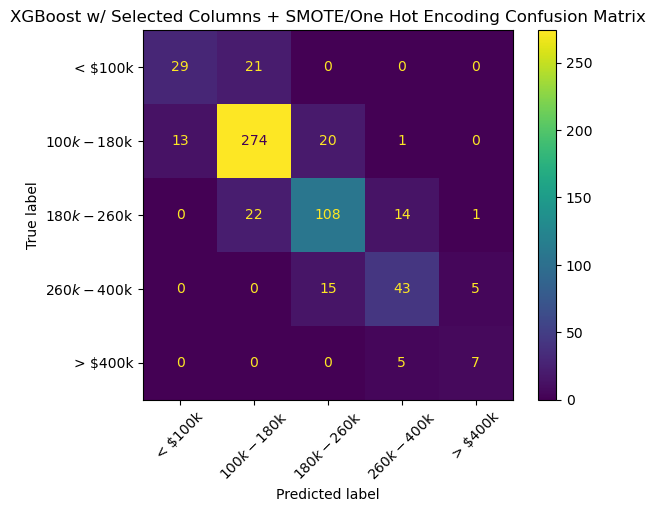

In [113]:
confusion=ConfusionMatrixDisplay(scores['XGB Select SMOTE+OH']['ConfusionMatrix'],display_labels=labels)
confusion.plot()
plt.title(f'XGBoost w/ Selected Columns + SMOTE/One Hot Encoding Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

### Label Encoding

In [82]:
need_label_encoding=['Lot Shape','Utilities','Land Slope','Exter Qual','Exter Cond','Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2','Heating QC','Electrical','Kitchen Qual','Functional','Fireplace Qu','Garage Finish','Garage Qual','Garage Cond','Paved Drive','Pool QC','Fence']

In [83]:
for col in df[need_label_encoding].columns:
    vals=df[col].unique()
    print(f'{col}: {vals}')

Lot Shape: ['IR1' 'Reg' 'IR2' 'IR3']
Utilities: ['AllPub' 'NoSewr' 'NoSeWa']
Land Slope: ['Gtl' 'Mod' 'Sev']
Exter Qual: ['TA' 'Gd' 'Ex' 'Fa']
Exter Cond: ['TA' 'Gd' 'Fa' 'Po' 'Ex']
Bsmt Qual: ['TA' 'Gd' 'Ex' 'No Basement' 'Fa' 'Po']
Bsmt Cond: ['Gd' 'TA' 'No Basement' 'Po' 'Fa' 'Ex']
Bsmt Exposure: ['Gd' 'No' 'Mn' 'Av' 'No Basement']
BsmtFin Type 1: ['BLQ' 'Rec' 'ALQ' 'GLQ' 'Unf' 'LwQ' 'No Basement']
BsmtFin Type 2: ['Unf' 'LwQ' 'BLQ' 'Rec' 'No Basement' 'GLQ' 'ALQ']
Heating QC: ['Fa' 'TA' 'Ex' 'Gd' 'Po']
Electrical: ['SBrkr' 'FuseA' 'FuseF' 'FuseP' 'Mix']
Kitchen Qual: ['TA' 'Gd' 'Ex' 'Fa' 'Po']
Functional: ['Typ' 'Mod' 'Min1' 'Min2' 'Maj1' 'Maj2' 'Sev' 'Sal']
Fireplace Qu: ['Gd' 'No Fireplace' 'TA' 'Po' 'Ex' 'Fa']
Garage Finish: ['Fin' 'Unf' 'RFn' 'No Garage']
Garage Qual: ['TA' 'No Garage' 'Fa' 'Gd' 'Ex' 'Po']
Garage Cond: ['TA' 'No Garage' 'Fa' 'Gd' 'Ex' 'Po']
Paved Drive: ['P' 'Y' 'N']
Pool QC: ['No Pool' 'Ex' 'Gd' 'TA' 'Fa']
Fence: ['No Fence' 'MnPrv' 'GdPrv' 'GdWo' 'MnWw']


In [94]:
ordinal_encoding_labels={
    'Lot Shape': ['Reg','IR1','IR2','IR3'],
    'Utilities': ['AllPub','NoSewr','NoSeWa'],
    'Land Slope': ['Gtl','Mod','Sev'],
    'Exter Qual': ['Ex','Gd','TA','Fa'],
    'Exter Cond': ['Ex','Gd','TA','Fa','Po'],
    'Bsmt Qual': ['Ex','Gd','TA','Fa','Po','No Basement'],
    'Bsmt Cond': ['Ex','Gd','TA','Fa','Po','No Basement'],
    'Bsmt Exposure': ['Gd','Av','Mn','No','No Basement'],
    'BsmtFin Type 1': ['GLQ','ALQ','BLQ','Rec','LwQ','Unf','No Basement'],
    'BsmtFin Type 2': ['GLQ','ALQ','BLQ','Rec','LwQ','Unf','No Basement'],
    'Heating QC': ['Ex','Gd','TA','Fa','Po'],
    'Electrical':['SBrkr','FuseA','FuseF','FuseP','Mix'],
    'Kitchen Qual': ['Ex','Gd','TA','Fa','Po'],
    'Functional': ['Typ','Min1','Min2','Mod','Maj1','Maj2','Sev','Sal'],
    'Fireplace Qu': ['Ex','Gd','TA','Fa','Po','No Fireplace'],
    'Garage Finish': ['Fin','RFn','Unf','No Garage'],
    'Garage Qual': ['Ex','Gd','TA','Fa','Po','No Garage'],
    'Garage Cond': ['Ex','Gd','TA','Fa','Po','No Garage'],
    'Paved Drive': ['Y','P','N'],
    'Pool QC': ['Ex','Gd','TA','Fa','No Pool'],
    'Fence': ['GdPrv','MnPrv','GdWo','MnWw','No Fence']
    }

In [95]:
#ordinal labeling
ord_cols=df[need_label_encoding]

for col in ord_cols.columns:
    encoder=OrdinalEncoder(categories=[ordinal_encoding_labels[col]])
    ord_cols[col]=encoder.fit_transform(ord_cols[[col]])

ord_cols

/var/folders/rs/56dc52116fdc6_zgn1vcs_fr0000gp/T/ipykernel_17663/1218036202.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ord_cols[col]=encoder.fit_transform(ord_cols[[col]])
/var/folders/rs/56dc52116fdc6_zgn1vcs_fr0000gp/T/ipykernel_17663/1218036202.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ord_cols[col]=encoder.fit_transform(ord_cols[[col]])
/var/folders/rs/56dc52116fdc6_zgn1vcs_fr0000gp/T/ipykernel_17663/1218036202.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

,Lot Shape,Utilities,Land Slope,Exter Qual,Exter Cond,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,...,Electrical,Kitchen Qual,Functional,Fireplace Qu,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence
0,1.0,0.0,0.0,2.0,2.0,2.0,1.0,0.0,2.0,5.0,...,0.0,2.0,0.0,1.0,0.0,2.0,2.0,1.0,4.0,4.0
1,0.0,0.0,0.0,2.0,2.0,2.0,2.0,3.0,3.0,4.0,...,0.0,2.0,0.0,5.0,2.0,2.0,2.0,0.0,4.0,1.0
2,1.0,0.0,0.0,2.0,2.0,2.0,2.0,3.0,1.0,5.0,...,0.0,1.0,0.0,5.0,2.0,2.0,2.0,0.0,4.0,4.0
3,0.0,0.0,0.0,1.0,2.0,2.0,2.0,3.0,1.0,5.0,...,0.0,0.0,0.0,2.0,0.0,2.0,2.0,0.0,4.0,4.0
4,1.0,0.0,0.0,2.0,2.0,1.0,2.0,3.0,0.0,5.0,...,0.0,2.0,0.0,2.0,0.0,2.0,2.0,0.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,1.0,0.0,0.0,2.0,2.0,2.0,2.0,1.0,0.0,5.0,...,0.0,2.0,0.0,5.0,2.0,2.0,2.0,0.0,4.0,0.0
2926,1.0,0.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,...,0.0,2.0,0.0,5.0,2.0,2.0,2.0,0.0,4.0,1.0
2927,0.0,0.0,0.0,2.0,2.0,1.0,2.0,1.0,0.0,5.0,...,0.0,2.0,0.0,5.0,3.0,5.0,5.0,0.0,4.0,1.0
2928,0.0,0.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0,4.0,...,0.0,2.0,0.0,2.0,1.0,2.0,2.0,0.0,4.0,4.0


In [98]:
full_df=pd.concat([nums.reset_index(drop=True),OHencoded.reset_index(drop=True),ord_cols.reset_index(drop=True),df[['Overall Qual','Overall Cond','Price Bins']].reset_index(drop=True)],axis=1)
full_df

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Fireplace Qu,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Overall Qual,Overall Cond,Price Bins
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,1.0,0.0,2.0,2.0,1.0,4.0,4.0,6,5,$180k-$260k
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,5.0,2.0,2.0,2.0,0.0,4.0,1.0,5,6,$100k-$180k
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,5.0,2.0,2.0,2.0,0.0,4.0,4.0,6,6,$100k-$180k
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,2.0,0.0,2.0,2.0,0.0,4.0,4.0,7,5,$180k-$260k
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,2.0,0.0,2.0,2.0,0.0,4.0,1.0,5,5,$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2883,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,5.0,2.0,2.0,2.0,0.0,4.0,0.0,6,6,$100k-$180k
2884,74.0,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,5.0,2.0,2.0,2.0,0.0,4.0,1.0,5,5,$100k-$180k
2885,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,5.0,3.0,5.0,5.0,0.0,4.0,1.0,5,5,$100k-$180k
2886,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,2.0,1.0,2.0,2.0,0.0,4.0,4.0,5,5,$100k-$180k


### Full DF w/ One Hot and Ordinal Encoding Modeling (XGBoost + SMOTE)

In [99]:
#train/test split
full_X = full_df.iloc[:,:-1] #excluding  target var
full_y = full_df.iloc[:,-1:] #only categorical target var

#ordinal labeling of target variable
labels=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k']
encoder=OrdinalEncoder(categories=[labels])
full_y=encoder.fit_transform(full_y)

full_X_train, full_X_test, full_y_train, full_y_test = train_test_split(full_X, full_y, test_size=0.2,stratify=y,random_state=123)

In [100]:
full_smote_pipeline=pipelineIM([('smote', SMOTE(random_state=123)),('xgb', xgb.XGBClassifier())])
full_smote_pipeline.fit(full_X_train, full_y_train)

Pipeline(steps=[('smote', SMOTE(random_state=123)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [122]:
#Cross-Validation
cv_scores=cross_val_score(full_smote_pipeline, full_X_train, full_y_train, cv=5, scoring='f1_macro')
print("Cross-Validation F1 Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())

Cross-Validation F1 Scores: [0.82866061 0.82097023 0.76275138 0.77843968 0.76750684]
Mean F1 Score: 0.7916657494965367


In [101]:
# predictions
y_pred_full_SMOTE = full_smote_pipeline.predict(full_X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB Full DF SMOTE']=dict()
scores['XGB Full DF SMOTE']['Accuracy'] = accuracy_score(full_y_test, y_pred_full_SMOTE)
scores['XGB Full DF SMOTE']['Precision'] = precision_score(full_y_test, y_pred_full_SMOTE,average='macro')
scores['XGB Full DF SMOTE']['Recall'] = recall_score(full_y_test, y_pred_full_SMOTE,average='macro')
scores['XGB Full DF SMOTE']['F1'] = f1_score(full_y_test, y_pred_full_SMOTE,average='macro')
scores['XGB Full DF SMOTE']['ConfusionMatrix']=confusion_matrix(full_y_test,full_smote_pipeline.predict(full_X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost OH,0.804498,0.756868,0.70395,0.726767,[[ 28 22 0 0 0] [ 10 277 21 0 0] [ 0 27 106 11 1] [ 0 0 14 47 2] [ 0 0 0 5 7]]
XGBoost PCA OH,0.782007,0.697872,0.670496,0.680096,[[ 27 23 0 0 0] [ 10 275 22 1 0] [ 0 28 104 11 2] [ 0 1 18 39 5] [ 0 0 0 5 7]]
XGB SMOTE+OH,0.807958,0.769603,0.766213,0.764015,[[ 31 19 0 0 0] [ 7 274 26 1 0] [ 0 25 103 16 1] [ 0 0 11 49 3] [ 0 0 0 2 10]]
XGB SMOTE+OH HT,0.799308,0.73979,0.755391,0.7428,[[ 31 19 0 0 0] [ 9 272 26 1 0] [ 0 25 103 16 1] [ 0 0 12 46 5] [ 0 0 0 2 10]]
XGB Select SMOTE+OH,0.797578,0.706215,0.696062,0.699955,[[ 29 21 0 0 0] [ 13 274 20 1 0] [ 0 22 108 14 1] [ 0 0 15 43 5] [ 0 0 0 5 7]]
XGB Full DF SMOTE,0.83391,0.796247,0.806793,0.799458,[[ 36 14 0 0 0] [ 8 277 23 0 0] [ 0 27 105 12 1] [ 0 0 6 54 3] [ 0 0 0 2 10]]


In [109]:
print(classification_report(full_y_test, y_pred_full_SMOTE))

              precision    recall  f1-score   support

         0.0       0.82      0.72      0.77        50
         1.0       0.87      0.90      0.88       308
         2.0       0.78      0.72      0.75       145
         3.0       0.79      0.86      0.82        63
         4.0       0.71      0.83      0.77        12

    accuracy                           0.83       578
   macro avg       0.80      0.81      0.80       578
weighted avg       0.83      0.83      0.83       578



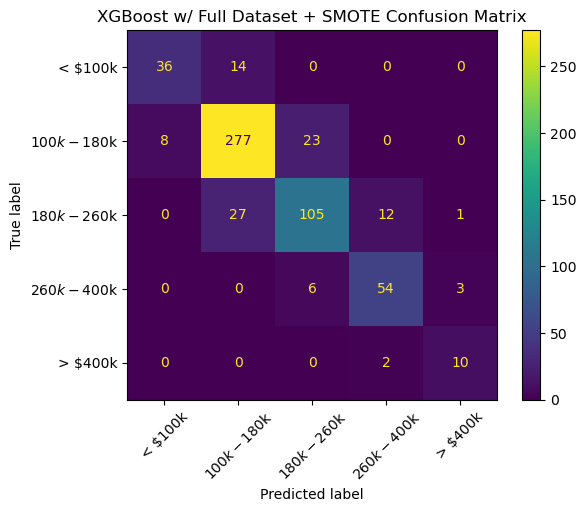

In [110]:
confusion=ConfusionMatrixDisplay(scores['XGB Full DF SMOTE']['ConfusionMatrix'],display_labels=labels)
confusion.plot()
plt.title(f'XGBoost w/ Full Dataset + SMOTE Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

### XAI: Full DF w/ One Hot and Ordinal Encoding Modeling (XGBoost + SMOTE)

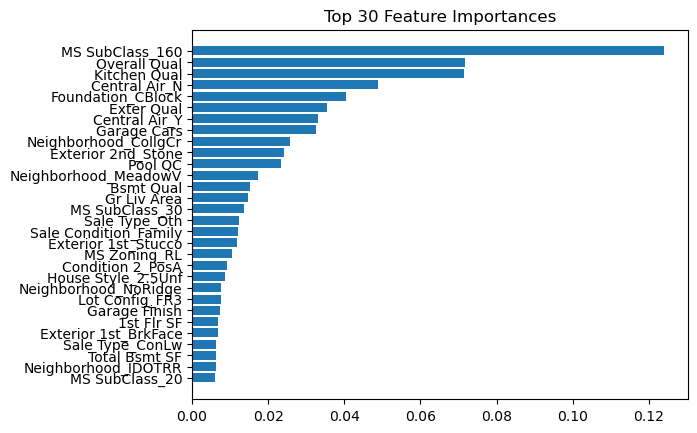

In [117]:
full_model=full_smote_pipeline.named_steps['xgb']
full_importance=full_model.feature_importances_
full_feature_importance=pd.DataFrame({'feature': full_X_train.columns,'importance': full_model.feature_importances_}).sort_values('importance', ascending=False)

#Plot of Feature Importance
full_top_30=full_feature_importance.head(30)

plt.figure()
plt.barh(full_top_30['feature'], full_top_30['importance'])
plt.gca().invert_yaxis()
plt.title('Top 30 Feature Importances')
plt.show()

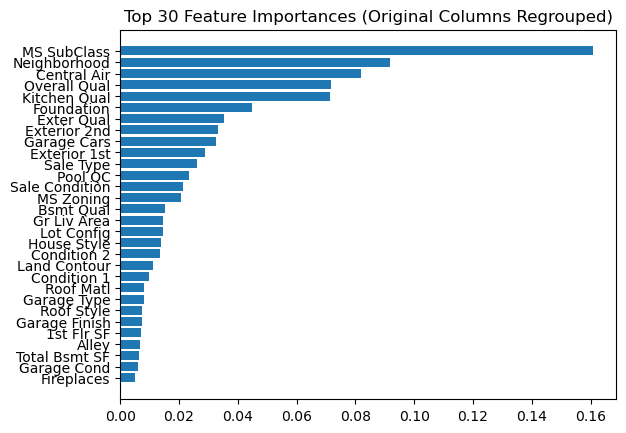

In [118]:
#Feature Importance after regrouping origincal columns (pre-One Hot Encoding)
full_original_OH_cols = {col: col.split('_')[0] for col in full_X_train.columns}
full_feature_importance['original_feature']=full_feature_importance['feature'].map(full_original_OH_cols)

full_agg_importance = (full_feature_importance.groupby('original_feature')['importance'].sum().sort_values(ascending=False).reset_index())

#Plot of Feature Importance (Original Columns Regrouped)
full_agg_top_30=full_agg_importance.head(30)

plt.figure()
plt.barh(full_agg_top_30['original_feature'], full_agg_top_30['importance'])
plt.gca().invert_yaxis()
plt.title('Top 30 Feature Importances (Original Columns Regrouped)')
plt.show()

In [129]:
import shap

In [157]:
full_X_test_DF=pd.DataFrame(full_X_test)
full_X_test_DF

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Functional,Fireplace Qu,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Overall Qual,Overall Cond
1164,38.0,14963,1996,1996,0.0,786.0,0.0,474.0,1260.0,1288,...,0.0,1.0,0.0,2.0,2.0,0.0,4.0,4.0,8,5
1606,64.0,9556,1992,1993,52.0,0.0,0.0,1168.0,1168.0,1187,...,0.0,5.0,1.0,2.0,2.0,0.0,4.0,4.0,7,5
448,80.0,10307,2007,2008,176.0,876.0,0.0,474.0,1350.0,1358,...,0.0,1.0,1.0,2.0,2.0,0.0,4.0,4.0,7,5
2322,78.0,10140,1976,1976,0.0,194.0,0.0,638.0,832.0,832,...,0.0,2.0,1.0,2.0,2.0,0.0,4.0,2.0,7,5
581,80.0,9650,1977,1977,360.0,686.0,0.0,664.0,1350.0,1334,...,0.0,2.0,1.0,2.0,2.0,0.0,4.0,4.0,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2669,70.0,8414,1963,2003,0.0,663.0,0.0,396.0,1059.0,1068,...,0.0,5.0,1.0,2.0,2.0,0.0,4.0,1.0,6,8
368,48.0,17043,1979,1998,0.0,0.0,0.0,1362.0,1362.0,1586,...,0.0,2.0,2.0,2.0,2.0,0.0,4.0,4.0,6,5
2729,80.0,12000,1968,1968,0.0,853.0,0.0,535.0,1388.0,1388,...,0.0,4.0,1.0,2.0,2.0,0.0,4.0,4.0,6,5
1655,21.0,2205,1973,1973,567.0,312.0,0.0,213.0,525.0,525,...,0.0,5.0,2.0,2.0,2.0,0.0,4.0,4.0,6,6


In [160]:
full_model_b=full_smote_pipeline.named_steps['xgb'].get_booster()

#### SHAP Global per Class

< $100k


/var/folders/rs/56dc52116fdc6_zgn1vcs_fr0000gp/T/ipykernel_17663/2031958254.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,i], full_X_test_DF)


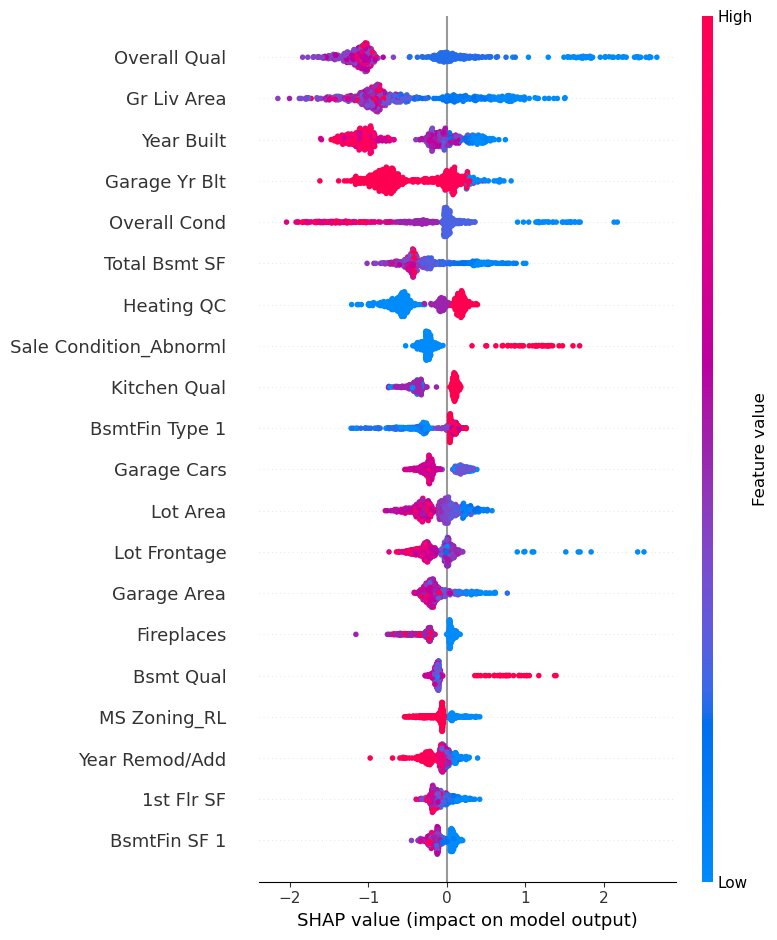

$100k-$180k


/var/folders/rs/56dc52116fdc6_zgn1vcs_fr0000gp/T/ipykernel_17663/2031958254.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,i], full_X_test_DF)


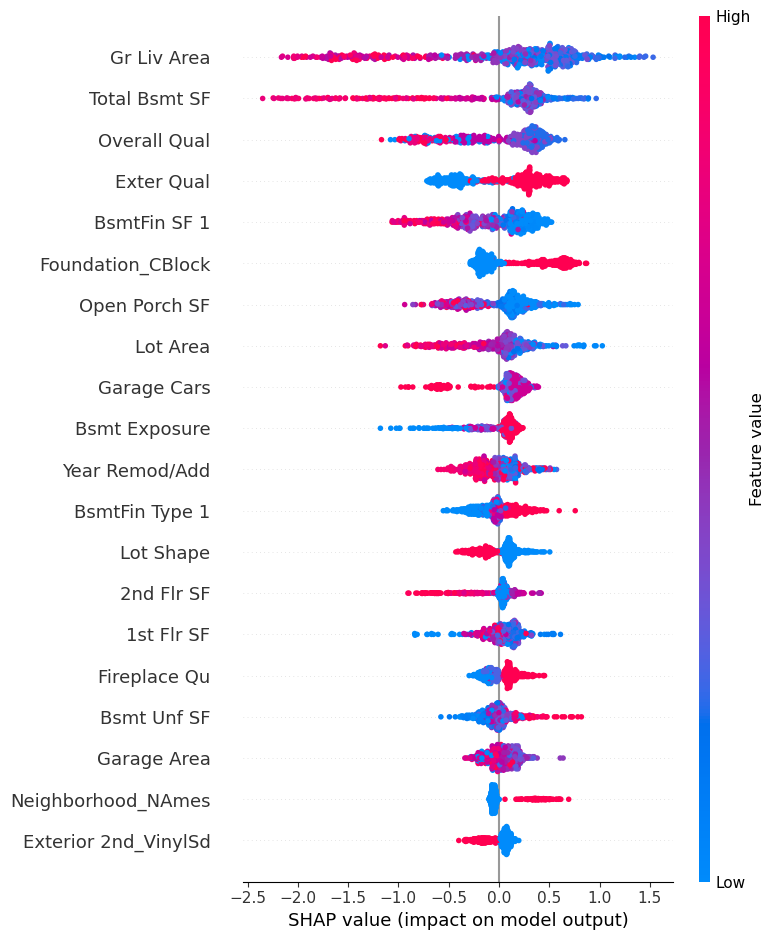

$180k-$260k


/var/folders/rs/56dc52116fdc6_zgn1vcs_fr0000gp/T/ipykernel_17663/2031958254.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,i], full_X_test_DF)


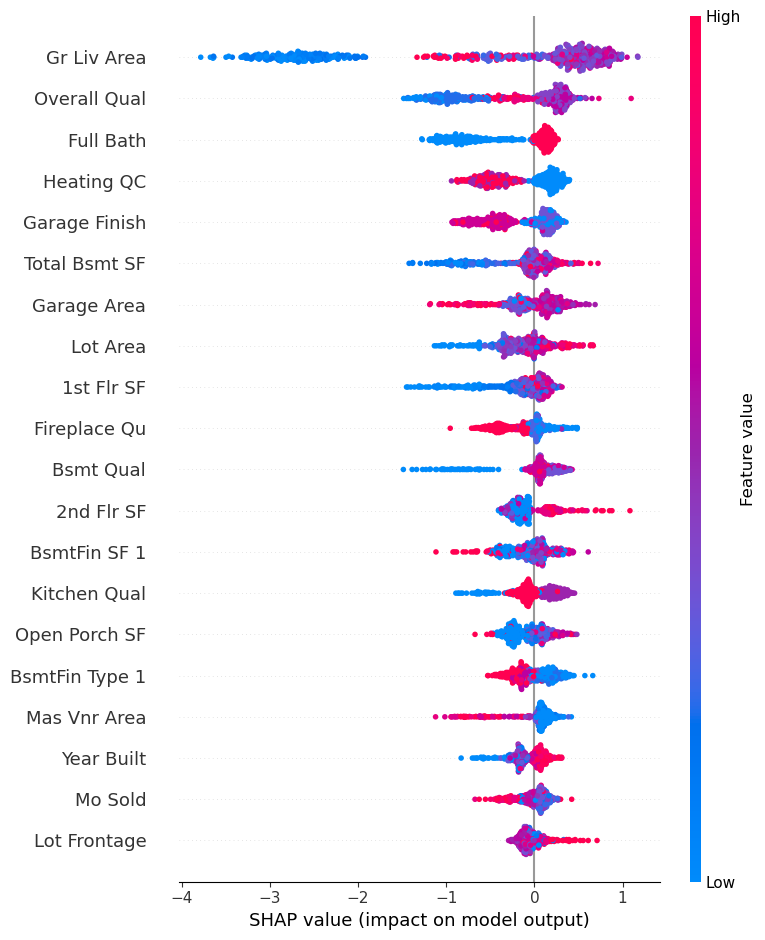

$260k-$400k


/var/folders/rs/56dc52116fdc6_zgn1vcs_fr0000gp/T/ipykernel_17663/2031958254.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,i], full_X_test_DF)


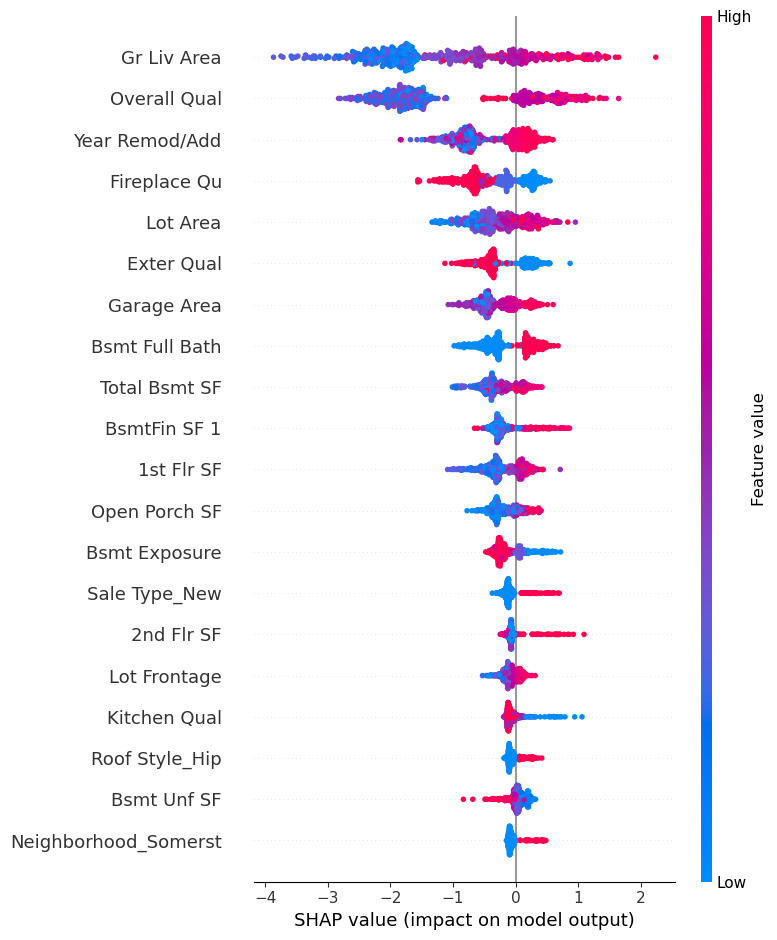

> $400k


/var/folders/rs/56dc52116fdc6_zgn1vcs_fr0000gp/T/ipykernel_17663/2031958254.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,i], full_X_test_DF)


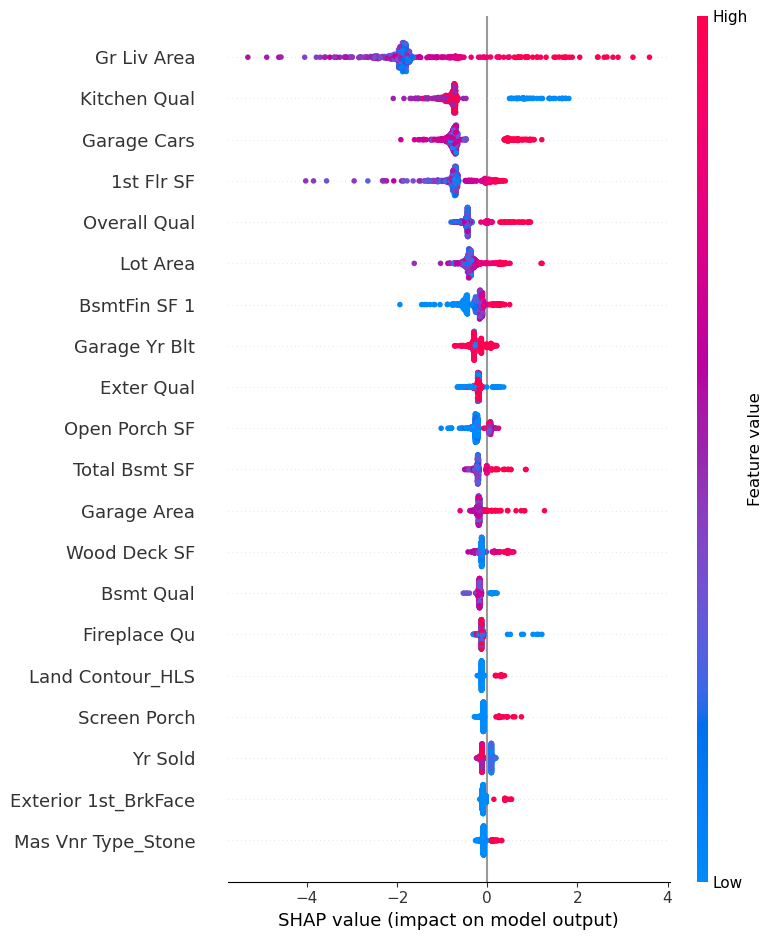

In [194]:
shap.initjs()
explainer=shap.TreeExplainer(full_model_b)
shap_values=explainer.shap_values(full_X_test_DF)
for i in range(5):
    print(f'{labels[i]}')
    shap.summary_plot(shap_values[:,:,i], full_X_test_DF)

#### SHAP Local

In [201]:
ex=explainer.expected_value
for i in range(5):
    print(f'{labels[i]} Expected Value: {explainer.expected_value[i]:.4f}')

< $100k Expected Value: 0.6066
$100k-$180k Expected Value: 0.6785
$180k-$260k Expected Value: 0.6202
$260k-$400k Expected Value: 0.5756
> $400k Expected Value: 0.1914


##### Class 2 Example ($180k-$260k)

In [250]:
print(f'True: {int(full_y_test[0])}')
print(f'Predicted: {full_smote_pipeline.predict(full_X_test)[0]}')

True: 2
Predicted: 2


/var/folders/rs/56dc52116fdc6_zgn1vcs_fr0000gp/T/ipykernel_17663/3349953112.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f'True: {int(full_y_test[0])}')


In [251]:
print(f'True Label: {labels[int(full_y_test[0])]} (Class {int(full_y_test[0])})')
shap.force_plot(explainer.expected_value[2],shap_values[0,:,2],full_X_test.iloc[0])

True Label: $180k-$260k (Class 2)


/var/folders/rs/56dc52116fdc6_zgn1vcs_fr0000gp/T/ipykernel_17663/3846406974.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f'True Label: {labels[int(full_y_test[0])]} (Class {int(full_y_test[0])})')


### Hyperparameter Tuning: Full DF w/ One Hot and Ordinal Encoding Modeling (XGBoost + SMOTE)

In [107]:
#Hyperparameter Tuning
param_grid2 = {
    'xgb__n_estimators': [600, 800, 1000, 1200],
    'xgb__max_depth': [7, 9, 11, 13],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.3],
    'xgb__colsample_bytree': [0.7, 0.9, 1],
    'xgb__gamma': [0, 0.1, 0.3, 0.5],
    'xgb__reg_alpha': [0, 0.1, 0.5, 1],
    'xgb__reg_lambda': [1, 3, 5, 10]
}
grid_search2 = RandomizedSearchCV(full_smote_pipeline, param_grid2, cv=5, scoring='f1_macro', n_iter=50, verbose=2)
grid_search2.fit(full_X_train, full_y_train)
best_params2 = grid_search2.best_params_
print("Best Hyperparameters:", best_params2)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END xgb__colsample_bytree=1, xgb__gamma=0.1, xgb__learning_rate=0.1, xgb__max_depth=9, xgb__n_estimators=800, xgb__reg_alpha=0.1, xgb__reg_lambda=5; total time=   4.2s
[CV] END xgb__colsample_bytree=1, xgb__gamma=0.1, xgb__learning_rate=0.1, xgb__max_depth=9, xgb__n_estimators=800, xgb__reg_alpha=0.1, xgb__reg_lambda=5; total time=   3.9s
[CV] END xgb__colsample_bytree=1, xgb__gamma=0.1, xgb__learning_rate=0.1, xgb__max_depth=9, xgb__n_estimators=800, xgb__reg_alpha=0.1, xgb__reg_lambda=5; total time=   4.1s
[CV] END xgb__colsample_bytree=1, xgb__gamma=0.1, xgb__learning_rate=0.1, xgb__max_depth=9, xgb__n_estimators=800, xgb__reg_alpha=0.1, xgb__reg_lambda=5; total time=   4.1s
[CV] END xgb__colsample_bytree=1, xgb__gamma=0.1, xgb__learning_rate=0.1, xgb__max_depth=9, xgb__n_estimators=800, xgb__reg_alpha=0.1, xgb__reg_lambda=5; total time=   4.0s
[CV] END xgb__colsample_bytree=0.7, xgb__gamma=0.5, xgb__learning_rate=0.

In [108]:
# Obtaining the best performing model from the grid search results
best_model2 = grid_search2.best_estimator_

# predictions
y_pred_full_ht = best_model2.predict(full_X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB Full DF SMOTE HT']=dict()
scores['XGB Full DF SMOTE HT']['Accuracy'] = accuracy_score(full_y_test, y_pred_full_ht)
scores['XGB Full DF SMOTE HT']['Precision'] = precision_score(full_y_test, y_pred_full_ht,average='macro')
scores['XGB Full DF SMOTE HT']['Recall'] = recall_score(full_y_test, y_pred_full_ht,average='macro')
scores['XGB Full DF SMOTE HT']['F1'] = f1_score(full_y_test, y_pred_full_ht,average='macro')
scores['XGB Full DF SMOTE HT']['ConfusionMatrix']=confusion_matrix(full_y_test,grid_search2.predict(full_X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))


,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost OH,0.804498,0.756868,0.70395,0.726767,[[ 28 22 0 0 0] [ 10 277 21 0 0] [ 0 27 106 11 1] [ 0 0 14 47 2] [ 0 0 0 5 7]]
XGBoost PCA OH,0.782007,0.697872,0.670496,0.680096,[[ 27 23 0 0 0] [ 10 275 22 1 0] [ 0 28 104 11 2] [ 0 1 18 39 5] [ 0 0 0 5 7]]
XGB SMOTE+OH,0.807958,0.769603,0.766213,0.764015,[[ 31 19 0 0 0] [ 7 274 26 1 0] [ 0 25 103 16 1] [ 0 0 11 49 3] [ 0 0 0 2 10]]
XGB SMOTE+OH HT,0.799308,0.73979,0.755391,0.7428,[[ 31 19 0 0 0] [ 9 272 26 1 0] [ 0 25 103 16 1] [ 0 0 12 46 5] [ 0 0 0 2 10]]
XGB Select SMOTE+OH,0.797578,0.706215,0.696062,0.699955,[[ 29 21 0 0 0] [ 13 274 20 1 0] [ 0 22 108 14 1] [ 0 0 15 43 5] [ 0 0 0 5 7]]
XGB Full DF SMOTE,0.83391,0.796247,0.806793,0.799458,[[ 36 14 0 0 0] [ 8 277 23 0 0] [ 0 27 105 12 1] [ 0 0 6 54 3] [ 0 0 0 2 10]]
XGB Full DF SMOTE HT,0.821799,0.780109,0.783459,0.779335,[[ 32 18 0 0 0] [ 9 274 24 1 0] [ 0 24 108 12 1] [ 0 0 9 51 3] [ 0 0 0 2 10]]


### Full DF w/ One Hot and Ordinal Encoding Modeling (XGBoost + SMOTE + PCA)

In [114]:
full_pca_pipeline=pipelineIM([('pca', PCA(n_components=75)),('smote', SMOTE(random_state=123)),('xgb', xgb.XGBClassifier())])
full_pca_pipeline.fit(full_X_train, full_y_train)

Pipeline(steps=[('pca', PCA(n_components=75)),
                ('smote', SMOTE(random_state=123)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [115]:
#examining PCA
pca2=full_pca_pipeline.named_steps['pca']
comps2=pd.DataFrame(pca2.components_,columns=full_X_train.columns,index=[f'PCA{i+1}' for i in range(pca2.n_components_)])

for i in range(5):
    print(f"\nTop features for PCA{i+1} on Full Dataset")
    print(comps2.iloc[i].abs().sort_values(ascending=False).head(10))


Top features for PCA1 on Full Dataset
Lot Area         0.999613
Gr Liv Area      0.016096
1st Flr SF       0.013799
Total Bsmt SF    0.012570
BsmtFin SF 1     0.010087
Garage Area      0.005157
Garage Yr Blt    0.003587
Mas Vnr Area     0.002601
Wood Deck SF     0.002294
2nd Flr SF       0.002256
Name: PCA1, dtype: float64

Top features for PCA2 on Full Dataset
Gr Liv Area      0.548788
Total Bsmt SF    0.515722
1st Flr SF       0.433746
BsmtFin SF 1     0.304675
Bsmt Unf SF      0.224093
Garage Area      0.190230
Garage Yr Blt    0.179209
Mas Vnr Area     0.119425
2nd Flr SF       0.114110
Wood Deck SF     0.045743
Name: PCA2, dtype: float64

Top features for PCA3 on Full Dataset
2nd Flr SF       0.591266
BsmtFin SF 1     0.522668
Gr Liv Area      0.417614
Bsmt Unf SF      0.330506
Total Bsmt SF    0.232779
1st Flr SF       0.182689
Garage Yr Blt    0.056724
BsmtFin SF 2     0.040617
Misc Val         0.016875
Open Porch SF    0.015274
Name: PCA3, dtype: float64

Top features for PCA4

In [116]:
# predictions
y_pred_full_PCA = full_pca_pipeline.predict(full_X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB Full DF PCA']=dict()
scores['XGB Full DF PCA']['Accuracy'] = accuracy_score(full_y_test, y_pred_full_PCA)
scores['XGB Full DF PCA']['Precision'] = precision_score(full_y_test, y_pred_full_PCA,average='macro')
scores['XGB Full DF PCA']['Recall'] = recall_score(full_y_test, y_pred_full_PCA,average='macro')
scores['XGB Full DF PCA']['F1'] = f1_score(full_y_test, y_pred_full_PCA,average='macro')
scores['XGB Full DF PCA']['ConfusionMatrix']=confusion_matrix(full_y_test,full_pca_pipeline.predict(full_X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost OH,0.804498,0.756868,0.70395,0.726767,[[ 28 22 0 0 0] [ 10 277 21 0 0] [ 0 27 106 11 1] [ 0 0 14 47 2] [ 0 0 0 5 7]]
XGBoost PCA OH,0.782007,0.697872,0.670496,0.680096,[[ 27 23 0 0 0] [ 10 275 22 1 0] [ 0 28 104 11 2] [ 0 1 18 39 5] [ 0 0 0 5 7]]
XGB SMOTE+OH,0.807958,0.769603,0.766213,0.764015,[[ 31 19 0 0 0] [ 7 274 26 1 0] [ 0 25 103 16 1] [ 0 0 11 49 3] [ 0 0 0 2 10]]
XGB SMOTE+OH HT,0.799308,0.73979,0.755391,0.7428,[[ 31 19 0 0 0] [ 9 272 26 1 0] [ 0 25 103 16 1] [ 0 0 12 46 5] [ 0 0 0 2 10]]
XGB Select SMOTE+OH,0.797578,0.706215,0.696062,0.699955,[[ 29 21 0 0 0] [ 13 274 20 1 0] [ 0 22 108 14 1] [ 0 0 15 43 5] [ 0 0 0 5 7]]
XGB Full DF SMOTE,0.83391,0.796247,0.806793,0.799458,[[ 36 14 0 0 0] [ 8 277 23 0 0] [ 0 27 105 12 1] [ 0 0 6 54 3] [ 0 0 0 2 10]]
XGB Full DF SMOTE HT,0.821799,0.780109,0.783459,0.779335,[[ 32 18 0 0 0] [ 9 274 24 1 0] [ 0 24 108 12 1] [ 0 0 9 51 3] [ 0 0 0 2 10]]
XGB Full DF PCA,0.794118,0.710709,0.7597,0.727887,[[ 36 14 0 0 0] [ 15 271 21 1 0] [ 0 30 99 14 2] [ 0 0 13 43 7] [ 0 0 0 2 10]]


### Modeling: XGBoost w/ oversampling

In [254]:
from catboost import CatBoostClassifier
from imblearn.over_sampling import RandomOverSampler

In [255]:
full_os_pipeline=pipelineIM([('oversampling', RandomOverSampler(random_state=123)),('xgb', xgb.XGBClassifier())])
full_os_pipeline.fit(full_X_train, full_y_train)

Pipeline(steps=[('oversampling', RandomOverSampler(random_state=123)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [256]:
# predictions
y_pred_full_os = full_os_pipeline.predict(full_X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB Full DF OS']=dict()
scores['XGB Full DF OS']['Accuracy'] = accuracy_score(full_y_test, y_pred_full_os)
scores['XGB Full DF OS']['Precision'] = precision_score(full_y_test, y_pred_full_os,average='macro')
scores['XGB Full DF OS']['Recall'] = recall_score(full_y_test, y_pred_full_os,average='macro')
scores['XGB Full DF OS']['F1'] = f1_score(full_y_test, y_pred_full_os,average='macro')
scores['XGB Full DF OS']['ConfusionMatrix']=confusion_matrix(full_y_test,y_pred_full_os)

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost OH,0.804498,0.756868,0.70395,0.726767,[[ 28 22 0 0 0] [ 10 277 21 0 0] [ 0 27 106 11 1] [ 0 0 14 47 2] [ 0 0 0 5 7]]
XGBoost PCA OH,0.782007,0.697872,0.670496,0.680096,[[ 27 23 0 0 0] [ 10 275 22 1 0] [ 0 28 104 11 2] [ 0 1 18 39 5] [ 0 0 0 5 7]]
XGB SMOTE+OH,0.807958,0.769603,0.766213,0.764015,[[ 31 19 0 0 0] [ 7 274 26 1 0] [ 0 25 103 16 1] [ 0 0 11 49 3] [ 0 0 0 2 10]]
XGB SMOTE+OH HT,0.799308,0.73979,0.755391,0.7428,[[ 31 19 0 0 0] [ 9 272 26 1 0] [ 0 25 103 16 1] [ 0 0 12 46 5] [ 0 0 0 2 10]]
XGB Select SMOTE+OH,0.797578,0.706215,0.696062,0.699955,[[ 29 21 0 0 0] [ 13 274 20 1 0] [ 0 22 108 14 1] [ 0 0 15 43 5] [ 0 0 0 5 7]]
XGB Full DF SMOTE,0.83391,0.796247,0.806793,0.799458,[[ 36 14 0 0 0] [ 8 277 23 0 0] [ 0 27 105 12 1] [ 0 0 6 54 3] [ 0 0 0 2 10]]
XGB Full DF SMOTE HT,0.821799,0.780109,0.783459,0.779335,[[ 32 18 0 0 0] [ 9 274 24 1 0] [ 0 24 108 12 1] [ 0 0 9 51 3] [ 0 0 0 2 10]]
XGB Full DF PCA,0.794118,0.710709,0.7597,0.727887,[[ 36 14 0 0 0] [ 15 271 21 1 0] [ 0 30 99 14 2] [ 0 0 13 43 7] [ 0 0 0 2 10]]
XGB Full DF OS,0.84083,0.809477,0.808815,0.808627,[[ 37 13 0 0 0] [ 10 278 19 1 0] [ 0 26 110 8 1] [ 0 0 10 51 2] [ 0 0 0 2 10]]


In [257]:
print(classification_report(full_y_test, y_pred_full_os))

              precision    recall  f1-score   support

         0.0       0.79      0.74      0.76        50
         1.0       0.88      0.90      0.89       308
         2.0       0.79      0.76      0.77       145
         3.0       0.82      0.81      0.82        63
         4.0       0.77      0.83      0.80        12

    accuracy                           0.84       578
   macro avg       0.81      0.81      0.81       578
weighted avg       0.84      0.84      0.84       578



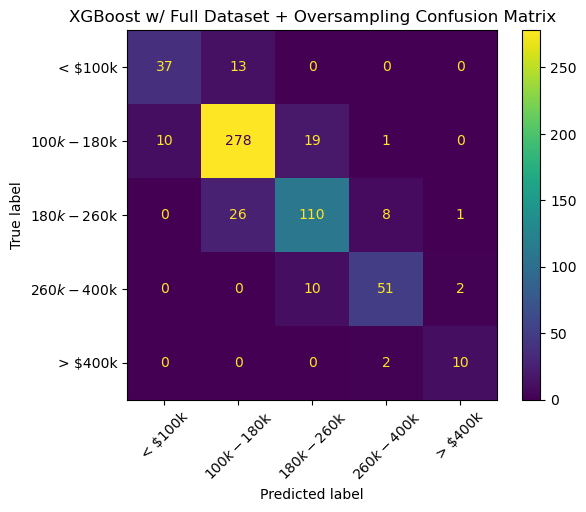

In [259]:
confusion=ConfusionMatrixDisplay(scores['XGB Full DF OS']['ConfusionMatrix'],display_labels=labels)
confusion.plot()
plt.title(f'XGBoost w/ Full Dataset + Oversampling Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

In [260]:
#saving model
import joblib
joblib.dump(pipeline, 'AmesHousing_model_pipeline.pkl')

['AmesHousing_model_pipeline.pkl']

### Appending Metrics to Scores File

In [258]:
scores_file=pd.DataFrame.from_dict(scores,orient='index')
scores_file.to_csv('cap2_metrics.csv', mode='a', header=False)